# Baseline PII Detection — Perbandingan Dataset Balance dan Imbalance

Notebook ini merupakan versi terperinci dari `train_baseline.py`. Eksperimen mempertahankan feature engineering dan konfigurasi model baseline, tetapi menjalankan **empat kombinasi eksperimen**:

1. Logistic Regression dengan dataset **balance**.
2. Linear SVM dengan dataset **balance**.
3. Logistic Regression dengan dataset **imbalance**.
4. Linear SVM dengan dataset **imbalance**.

Evaluasi akhir setiap eksperimen dilakukan menggunakan file **`test.json` milik skenario yang sama**. Notebook ini **tidak menggunakan `test_internal.json`**.

Tujuan analisis:

- menentukan model terbaik pada dataset imbalance;
- menentukan model terbaik pada dataset balance;
- menjelaskan apabila pemenang pada kedua skenario berbeda;
- membandingkan pengaruh balance vs imbalance untuk model yang sama;
- memilih baseline akhir antara Logistic Regression dan Linear SVM **hanya berdasarkan hasil dataset balance**.

> **Aturan keputusan utama:** model terbaik dipilih berdasarkan **token-level F1-score** tertinggi. Entity-level F1, precision, recall, serta jumlah kesalahan digunakan sebagai analisis pendukung.


## 1. Struktur folder yang wajib tersedia

Notebook mengharapkan struktur berikut secara ketat:

```text
data/processed/
├── balance/
│   ├── train.json
│   ├── val.json
│   └── test.json
└── imbalance/
    ├── train.json
    ├── val.json
    └── test.json
```

Setiap dokumen harus memiliki minimal field:

```text
document, tokens, labels
```

`val.json` digunakan untuk pemeriksaan distribusi dan integritas split. Hyperparameter pada eksperimen ini sudah ditetapkan agar perbandingan kedua dataset konsisten; evaluasi final tetap menggunakan `test.json`.


## 2. Import library


In [39]:
import os
import sys
import csv
import gc
import re
import json
import time
import hashlib
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack
from sklearn.feature_extraction import DictVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.exceptions import ConvergenceWarning
from IPython.display import display, Markdown

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)


## 3. Menentukan root project dan folder output

Fungsi berikut memungkinkan notebook dijalankan dari root project ataupun dari folder `models/baseline`.


In [40]:
def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'models' / 'baseline').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError(
        'Root project tidak ditemukan. Jalankan notebook dari dalam repository PII-Data-Detection.'
    )


BASE_DIR = find_project_root()
MODEL_DIR = BASE_DIR / 'models' / 'baseline'
PRED_DIR = BASE_DIR / 'results' / 'predictions'
METRIC_DIR = BASE_DIR / 'results' / 'metrics'
PLOT_DIR = MODEL_DIR / 'plots'

for directory in [MODEL_DIR, PRED_DIR, METRIC_DIR, PLOT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

SCENARIO_DIRS = {
    'balance': BASE_DIR / 'data' / 'processed' / 'balance',
    'imbalance': BASE_DIR / 'data' / 'processed' / 'imbalance',
}

print('Project root :', BASE_DIR)
print('Model output :', MODEL_DIR)
print('Prediction   :', PRED_DIR)
print('Metrics      :', METRIC_DIR)
print('Plots        :', PLOT_DIR)


Project root : D:\ml\PII-Data-Detection
Model output : D:\ml\PII-Data-Detection\models\baseline
Prediction   : D:\ml\PII-Data-Detection\results\predictions
Metrics      : D:\ml\PII-Data-Detection\results\metrics
Plots        : D:\ml\PII-Data-Detection\models\baseline\plots


## 4. Loader dataset dan validasi format

Loader hanya menerima `train.json`, `val.json`, dan **`test.json`**. Tidak ada fallback ke `test_internal.json`, sehingga kesalahan path akan langsung terlihat.


In [41]:
REQUIRED_SPLITS = ('train', 'val', 'test')


def split_path(scenario, split_name):
    if scenario not in SCENARIO_DIRS:
        raise ValueError(f'Skenario tidak dikenal: {scenario}')
    if split_name not in REQUIRED_SPLITS:
        raise ValueError(f'Split tidak dikenal: {split_name}')
    return SCENARIO_DIRS[scenario] / f'{split_name}.json'


def validate_required_files():
    missing = []
    for scenario in SCENARIO_DIRS:
        for split_name in REQUIRED_SPLITS:
            path = split_path(scenario, split_name)
            if not path.exists():
                missing.append(str(path))
    if missing:
        raise FileNotFoundError(
            'File dataset berikut belum tersedia:\n- ' + '\n- '.join(missing)
        )
    print('Semua file train.json, val.json, dan test.json tersedia untuk kedua skenario.')


def load_json(path):
    with open(path, 'r', encoding='utf-8') as file:
        return json.load(file)


def validate_documents(data, scenario, split_name):
    required = {'document', 'tokens', 'labels'}
    for index, doc in enumerate(data):
        missing = required - set(doc)
        if missing:
            raise ValueError(
                f'{scenario}/{split_name}: dokumen ke-{index} kehilangan field {sorted(missing)}.'
            )
        if len(doc['tokens']) != len(doc['labels']):
            raise ValueError(
                f"{scenario}/{split_name}: panjang tokens dan labels berbeda pada document={doc['document']}."
            )


def load_split(scenario, split_name, validate=True):
    path = split_path(scenario, split_name)
    data = load_json(path)
    if validate:
        validate_documents(data, scenario, split_name)
    return data


validate_required_files()


Semua file train.json, val.json, dan test.json tersedia untuk kedua skenario.


## 5. Pemeriksaan integritas split

Pemeriksaan ini memastikan satu document ID tidak muncul di lebih dari satu split dalam skenario yang sama. Overlap dapat menyebabkan data leakage karena model pernah melihat sebagian dokumen test saat training.

Document ID sintetis sebaiknya unik. Bila banyak dokumen sintetis menggunakan ID yang sama, notebook akan menampilkan peringatan.


In [42]:
def collect_document_ids(scenario, split_name):
    data = load_split(scenario, split_name)
    ids = [str(doc['document']) for doc in data]
    del data
    gc.collect()
    return ids


integrity_rows = []
for scenario in SCENARIO_DIRS:
    ids_by_split = {
        split_name: collect_document_ids(scenario, split_name)
        for split_name in REQUIRED_SPLITS
    }
    sets = {name: set(ids) for name, ids in ids_by_split.items()}

    overlap_train_val = sets['train'] & sets['val']
    overlap_train_test = sets['train'] & sets['test']
    overlap_val_test = sets['val'] & sets['test']

    train_counts = Counter(ids_by_split['train'])
    duplicate_train_ids = {doc_id: count for doc_id, count in train_counts.items() if count > 1}

    integrity_rows.append({
        'scenario': scenario,
        'train_records': len(ids_by_split['train']),
        'train_unique_ids': len(sets['train']),
        'val_records': len(ids_by_split['val']),
        'test_records': len(ids_by_split['test']),
        'train_val_overlap': len(overlap_train_val),
        'train_test_overlap': len(overlap_train_test),
        'val_test_overlap': len(overlap_val_test),
        'duplicate_train_ids': len(duplicate_train_ids),
    })

    if overlap_train_val or overlap_train_test or overlap_val_test:
        print(f'⚠ WARNING — overlap document ID ditemukan pada skenario {scenario}.')
    if duplicate_train_ids:
        example = list(duplicate_train_ids.items())[:5]
        print(f'⚠ {scenario}: ada document ID berulang pada train. Contoh: {example}')

integrity_df = pd.DataFrame(integrity_rows)
display(integrity_df)

if (
    integrity_df[['train_val_overlap', 'train_test_overlap', 'val_test_overlap']]
    .to_numpy()
    .sum() == 0
):
    print('✓ Tidak ada overlap document ID antar-split.')


⚠ WARNING — overlap document ID ditemukan pada skenario balance.
⚠ balance: ada document ID berulang pada train. Contoh: [('-1', 2304)]
⚠ WARNING — overlap document ID ditemukan pada skenario imbalance.


,scenario,train_records,train_unique_ids,val_records,test_records,train_val_overlap,train_test_overlap,val_test_overlap,duplicate_train_ids
0,balance,4659,2356,1021,1698,0,0,277,1
1,imbalance,4764,4764,1021,1698,0,1156,277,0


## 6. Exploratory Data Analysis (EDA)

Karena ini adalah token classification, ketimpangan utama dianalisis dari jumlah token berlabel `O` dibanding token PII (`label != O`).

Metrik yang ditampilkan:

- jumlah dokumen dan token;
- jumlah token PII dan non-PII;
- persentase token PII;
- jumlah label unik;
- rata-rata token per dokumen;
- distribusi setiap kelas PII.


In [43]:
def summarize_dataset(data, scenario, split_name):
    label_counts = Counter()
    document_lengths = []

    for doc in data:
        labels = doc['labels']
        label_counts.update(labels)
        document_lengths.append(len(doc['tokens']))

    total_tokens = sum(label_counts.values())
    pii_tokens = total_tokens - label_counts.get('O', 0)
    non_pii_tokens = label_counts.get('O', 0)

    summary = {
        'scenario': scenario,
        'split': split_name,
        'documents': len(data),
        'tokens': total_tokens,
        'pii_tokens': pii_tokens,
        'non_pii_tokens': non_pii_tokens,
        'pii_ratio_percent': 100 * pii_tokens / total_tokens if total_tokens else 0.0,
        'unique_labels': len(label_counts),
        'avg_tokens_per_document': np.mean(document_lengths) if document_lengths else 0.0,
    }

    label_rows = [
        {
            'scenario': scenario,
            'split': split_name,
            'label': label,
            'count': count,
            'percent': 100 * count / total_tokens if total_tokens else 0.0,
        }
        for label, count in sorted(label_counts.items())
    ]
    return summary, label_rows


summary_rows = []
label_rows = []

for scenario in SCENARIO_DIRS:
    for split_name in REQUIRED_SPLITS:
        print(f'Menganalisis {scenario}/{split_name}.json ...')
        data = load_split(scenario, split_name)
        summary, labels = summarize_dataset(data, scenario, split_name)
        summary_rows.append(summary)
        label_rows.extend(labels)
        del data
        gc.collect()

summary_df = pd.DataFrame(summary_rows)
label_df = pd.DataFrame(label_rows)

display(summary_df.style.format({
    'documents': '{:,.0f}',
    'tokens': '{:,.0f}',
    'pii_tokens': '{:,.0f}',
    'non_pii_tokens': '{:,.0f}',
    'pii_ratio_percent': '{:.4f}%',
    'avg_tokens_per_document': '{:,.2f}',
}))


Menganalisis balance/train.json ...
Menganalisis balance/val.json ...
Menganalisis balance/test.json ...
Menganalisis imbalance/train.json ...
Menganalisis imbalance/val.json ...
Menganalisis imbalance/test.json ...


,scenario,split,documents,tokens,pii_tokens,non_pii_tokens,pii_ratio_percent,unique_labels,avg_tokens_per_document
0,balance,train,"4,659","3,069,132","67,745","3,001,387",2.2073%,12,658.75
1,balance,val,"1,021","750,002",405,"749,597",0.0540%,7,734.58
2,balance,test,"1,698","1,260,090",658,"1,259,432",0.0522%,8,742.10
3,imbalance,train,"4,764","3,478,490","1,916","3,476,574",0.0551%,12,730.16
4,imbalance,val,"1,021","750,002",405,"749,597",0.0540%,7,734.58
5,imbalance,test,"1,698","1,260,090",658,"1,259,432",0.0522%,8,742.10


### 6.1 Interpretasi distribusi train balance dan imbalance


In [44]:
train_summary = summary_df[summary_df['split'] == 'train'].set_index('scenario')

balance_ratio = train_summary.loc['balance', 'pii_ratio_percent']
imbalance_ratio = train_summary.loc['imbalance', 'pii_ratio_percent']
ratio_multiplier = balance_ratio / imbalance_ratio if imbalance_ratio else np.inf

print(f"PII ratio train balance   : {balance_ratio:.4f}%")
print(f"PII ratio train imbalance : {imbalance_ratio:.4f}%")
print(f"Perbandingan              : {ratio_multiplier:.2f} kali")

if balance_ratio > imbalance_ratio:
    print(
        '\nDataset balance memberikan paparan token PII yang lebih besar kepada model. '
        'Hal ini biasanya membantu recall, tetapi precision dapat turun apabila pola PII '
        'tambahan kurang menyerupai data test atau model menjadi terlalu agresif menandai PII.'
    )
else:
    print(
        '\nPII ratio train balance tidak lebih tinggi daripada imbalance. '
        'Periksa kembali proses pembentukan dataset balance.'
    )


PII ratio train balance   : 2.2073%
PII ratio train imbalance : 0.0551%
Perbandingan              : 40.07 kali

Dataset balance memberikan paparan token PII yang lebih besar kepada model. Hal ini biasanya membantu recall, tetapi precision dapat turun apabila pola PII tambahan kurang menyerupai data test atau model menjadi terlalu agresif menandai PII.


### 6.2 Grafik persentase token PII per split


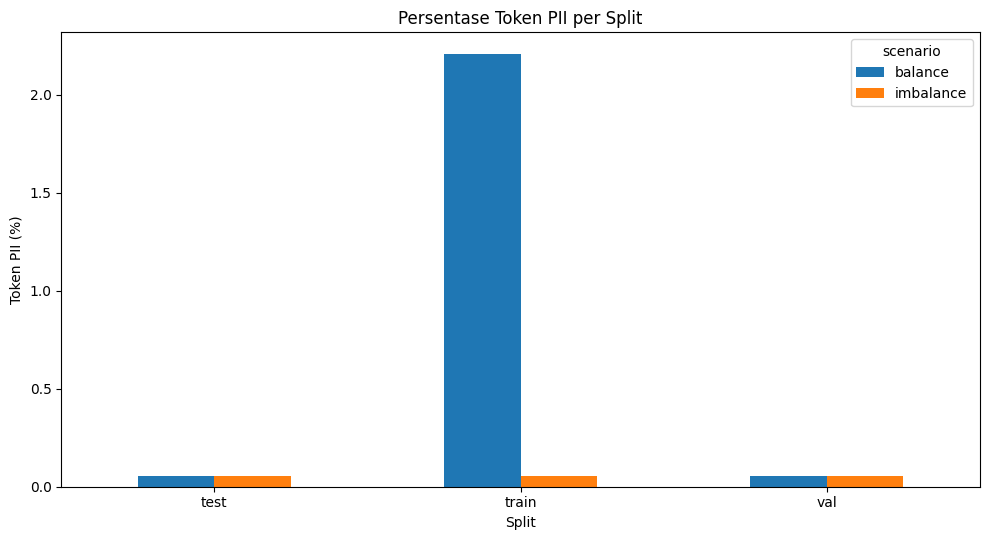

In [45]:
plot_data = summary_df.pivot(index='split', columns='scenario', values='pii_ratio_percent')
ax = plot_data.plot(kind='bar', figsize=(10, 5.5))
ax.set_title('Persentase Token PII per Split')
ax.set_xlabel('Split')
ax.set_ylabel('Token PII (%)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'dataset_pii_ratio.png', dpi=160, bbox_inches='tight')
plt.show()


### 6.3 Distribusi label PII pada training set

Label `O` dikeluarkan agar kelas PII terbaca. Skala log digunakan karena jumlah antarlabel dapat berbeda sangat jauh.


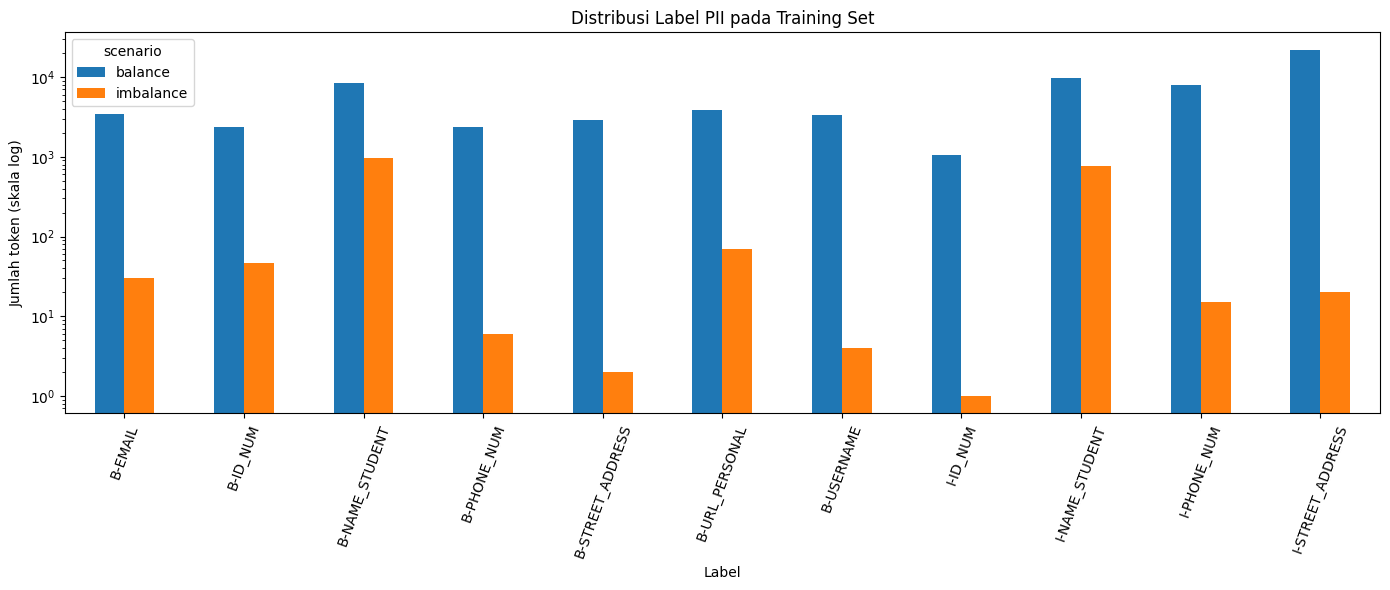

scenario,balance,imbalance
label,,
B-EMAIL,3467,30
B-ID_NUM,2376,47
B-NAME_STUDENT,8378,961
B-PHONE_NUM,2388,6
B-STREET_ADDRESS,2914,2
B-URL_PERSONAL,3888,70
B-USERNAME,3304,4
I-ID_NUM,1059,1
I-NAME_STUDENT,9884,760


In [46]:
train_pii_labels = label_df[
    (label_df['split'] == 'train') & (label_df['label'] != 'O')
]
label_pivot = train_pii_labels.pivot_table(
    index='label', columns='scenario', values='count', aggfunc='sum', fill_value=0
)

ax = label_pivot.plot(kind='bar', figsize=(14, 6), logy=True)
ax.set_title('Distribusi Label PII pada Training Set')
ax.set_xlabel('Label')
ax.set_ylabel('Jumlah token (skala log)')
ax.tick_params(axis='x', rotation=70)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'train_pii_label_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

display(label_pivot)


## 7. Apakah `test.json` balance dan imbalance sama?

Perbandingan balance vs imbalance paling kuat apabila kedua model diuji pada data test yang sama. Notebook tetap menggunakan `test.json` dari masing-masing skenario sesuai permintaan, lalu memeriksa fingerprint isi test.

- Jika fingerprint sama, perubahan hasil lebih layak dikaitkan dengan perbedaan data training.
- Jika fingerprint berbeda, selisih hasil merupakan gabungan pengaruh training distribution dan test distribution. Analisis tetap dapat dilakukan, tetapi tidak boleh menyatakan bahwa seluruh perubahan hanya disebabkan balancing.


In [47]:
def dataset_fingerprint(path):
    data = load_json(path)
    digest = hashlib.sha256()
    for doc in data:
        digest.update(str(doc['document']).encode('utf-8'))
        digest.update(b'\0')
        for token, label in zip(doc['tokens'], doc['labels']):
            digest.update(str(token).encode('utf-8'))
            digest.update(b'\x1f')
            digest.update(str(label).encode('utf-8'))
            digest.update(b'\x1e')
        digest.update(b'\n')
    del data
    gc.collect()
    return digest.hexdigest()


balance_test_hash = dataset_fingerprint(split_path('balance', 'test'))
imbalance_test_hash = dataset_fingerprint(split_path('imbalance', 'test'))
TEST_SETS_IDENTICAL = balance_test_hash == imbalance_test_hash

print('Fingerprint balance test  :', balance_test_hash)
print('Fingerprint imbalance test:', imbalance_test_hash)

if TEST_SETS_IDENTICAL:
    print('✓ Kedua test.json identik. Perbandingan balance vs imbalance dilakukan pada test yang sama.')
else:
    print(
        '⚠ Kedua test.json berbeda. Selisih hasil tidak hanya dipengaruhi data training, '
        'tetapi juga dapat dipengaruhi tingkat kesulitan dan distribusi test yang berbeda.'
    )


Fingerprint balance test  : 8c46830d08ab18c46dcc076a0118706bd1a2dfb80622ceb3c717d9f922b2152b
Fingerprint imbalance test: 8c46830d08ab18c46dcc076a0118706bd1a2dfb80622ceb3c717d9f922b2152b
✓ Kedua test.json identik. Perbandingan balance vs imbalance dilakukan pada test yang sama.


## 8. Feature engineering

Feature engineering dipertahankan dari `train_baseline.py` agar eksperimen sebanding.

### Handcrafted features

- lowercase token;
- bentuk karakter (`X` = huruf besar, `x` = huruf kecil, `d` = digit);
- panjang token;
- pola kapitalisasi dan digit;
- indikator email dan URL;
- prefix dan suffix 1–3 karakter;
- konteks token sebelumnya dan berikutnya;
- penanda awal/akhir dokumen (`BOS` dan `EOS`).

### TF-IDF karakter

`TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), min_df=2)` menangkap pola karakter di dalam token, misalnya bagian alamat email, URL, nomor identitas, atau pola nama.


In [48]:
def is_email(token):
    return bool(re.match(r'^[\w\.-]+@[\w\.-]+\.\w+$', token))


def is_url(token):
    lower = token.lower()
    return (
        'http' in lower
        or 'www' in lower
        or '.com' in lower
        or '.org' in lower
        or '.net' in lower
    )


def token_shape(token):
    result = []
    for char in token:
        if char.isupper():
            result.append('X')
        elif char.islower():
            result.append('x')
        elif char.isdigit():
            result.append('d')
        else:
            result.append(char)
    return ''.join(result)


def extract_features(tokens, index):
    token = tokens[index]
    lower = token.lower()

    features = {
        'token_lower': lower,
        'token_shape': token_shape(token),
        'token_length': len(token),
        'is_digit': token.isdigit(),
        'is_upper': token.isupper(),
        'is_title': token.istitle(),
        'has_digit': any(char.isdigit() for char in token),
        'has_alpha': any(char.isalpha() for char in token),
        'has_at': '@' in token,
        'has_dot': '.' in token,
        'has_dash': '-' in token,
        'is_email': is_email(token),
        'is_url': is_url(token),
        'prefix_1': lower[:1],
        'prefix_2': lower[:2],
        'prefix_3': lower[:3],
        'suffix_1': lower[-1:],
        'suffix_2': lower[-2:],
        'suffix_3': lower[-3:],
    }

    if index > 0:
        previous = tokens[index - 1]
        features.update({
            'prev_token': previous.lower(),
            'prev_shape': token_shape(previous),
            'prev_is_title': previous.istitle(),
        })
    else:
        features['BOS'] = True

    if index < len(tokens) - 1:
        following = tokens[index + 1]
        features.update({
            'next_token': following.lower(),
            'next_shape': token_shape(following),
            'next_is_title': following.istitle(),
        })
    else:
        features['EOS'] = True

    return features


## 9. Mengubah dokumen menjadi sampel token-level


In [49]:
def elapsed(start_time):
    return f'{time.time() - start_time:.2f}s'


def prepare_token_data(documents, dataset_name):
    handcrafted_features = []
    lowercase_tokens = []
    labels = []
    metadata = []

    total_documents = len(documents)
    start = time.time()
    print(f'Mempersiapkan {dataset_name}: {total_documents:,} dokumen')

    for doc_index, doc in enumerate(documents, start=1):
        document_id = doc['document']
        tokens = doc['tokens']
        doc_labels = doc['labels']

        for token_index, token in enumerate(tokens):
            handcrafted_features.append(extract_features(tokens, token_index))
            lowercase_tokens.append(token.lower())
            labels.append(doc_labels[token_index])
            metadata.append({
                'document_id': document_id,
                'token_index': token_index,
                'token': token,
                'true_label': doc_labels[token_index],
            })

        if doc_index % 500 == 0 or doc_index == total_documents:
            print(
                f'  {doc_index:,}/{total_documents:,} dokumen | '
                f'{len(lowercase_tokens):,} token | {elapsed(start)}'
            )

    return handcrafted_features, lowercase_tokens, labels, metadata


## 10. Vectorization dan cache per skenario

Logistic Regression dan Linear SVM pada skenario yang sama menggunakan matriks fitur yang sama. Cache mencegah feature extraction dan vectorization diulang dua kali.

> Matriks dapat memerlukan RAM besar. Setelah dua model pada satu skenario selesai, cache dapat dilepas dengan `release_scenario_cache("balance")` atau `release_scenario_cache("imbalance")`.


In [50]:
SCENARIO_CACHE = {}


def build_feature_matrix(dict_vectorizer, tfidf_vectorizer, features, tokens, fit=False):
    if fit:
        dict_matrix = dict_vectorizer.fit_transform(features)
        tfidf_matrix = tfidf_vectorizer.fit_transform(tokens)
    else:
        dict_matrix = dict_vectorizer.transform(features)
        tfidf_matrix = tfidf_vectorizer.transform(tokens)
    return hstack([dict_matrix, tfidf_matrix]).tocsr()


def prepare_scenario_matrices(scenario):
    if scenario in SCENARIO_CACHE:
        print(f'Menggunakan cache matriks untuk skenario {scenario}.')
        return SCENARIO_CACHE[scenario]

    train_documents = load_split(scenario, 'train')
    test_documents = load_split(scenario, 'test')

    train_features, train_tokens, y_train, _ = prepare_token_data(
        train_documents, f'{scenario}/train.json'
    )
    test_features, test_tokens, y_test, meta_test = prepare_token_data(
        test_documents, f'{scenario}/test.json'
    )

    dict_vectorizer = DictVectorizer(sparse=True)
    tfidf_vectorizer = TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(2, 4),
        min_df=2,
    )

    vector_start = time.time()
    X_train = build_feature_matrix(
        dict_vectorizer, tfidf_vectorizer, train_features, train_tokens, fit=True
    )
    X_test = build_feature_matrix(
        dict_vectorizer, tfidf_vectorizer, test_features, test_tokens, fit=False
    )

    print('Train matrix:', X_train.shape)
    print('Test matrix :', X_test.shape)
    print('Vectorization selesai dalam', elapsed(vector_start))

    data = {
        'scenario': scenario,
        'X_train': X_train,
        'y_train': y_train,
        'X_test': X_test,
        'y_test': y_test,
        'meta_test': meta_test,
        'dict_vectorizer': dict_vectorizer,
        'tfidf_vectorizer': tfidf_vectorizer,
    }
    SCENARIO_CACHE[scenario] = data

    del train_documents, test_documents
    del train_features, train_tokens, test_features, test_tokens
    gc.collect()
    return data


def release_scenario_cache(scenario=None):
    if scenario is None:
        SCENARIO_CACHE.clear()
        print('Semua cache skenario dilepas.')
    else:
        SCENARIO_CACHE.pop(scenario, None)
        print(f'Cache {scenario} dilepas.')
    gc.collect()


## 11. Evaluasi token-level dan entity-level

### Token-level

True positive dihitung ketika label PII diprediksi tepat, termasuk tipe BIO-nya. Label `O` tidak dihitung sebagai kelas target.

### Entity-level

Entity-level menggunakan exact match terhadap:

- document ID;
- tipe entitas;
- posisi awal;
- posisi akhir.

Evaluasi dilakukan per dokumen agar entitas di akhir satu dokumen tidak tersambung dengan entitas di awal dokumen berikutnya.


In [51]:
def extract_entities(labels):
    entities = []
    current_type = None
    current_start = None

    for index, label in enumerate(labels):
        if label == 'O':
            if current_type is not None:
                entities.append((current_type, current_start, index))
                current_type = None
                current_start = None
            continue

        prefix, entity_type = label.split('-', 1)
        if prefix == 'B' or entity_type != current_type:
            if current_type is not None:
                entities.append((current_type, current_start, index))
            current_type = entity_type
            current_start = index

    if current_type is not None:
        entities.append((current_type, current_start, len(labels)))
    return entities


def token_level_metrics(y_true, y_pred):
    labels = sorted((set(y_true) | set(y_pred)) - {'O'})
    total_tp = total_fp = total_fn = 0
    per_class = {}

    for label in labels:
        tp = sum(t == label and p == label for t, p in zip(y_true, y_pred))
        fp = sum(t != label and p == label for t, p in zip(y_true, y_pred))
        fn = sum(t == label and p != label for t, p in zip(y_true, y_pred))
        precision = tp / (tp + fp) if tp + fp else 0.0
        recall = tp / (tp + fn) if tp + fn else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
        per_class[label] = {
            'precision': round(precision, 6),
            'recall': round(recall, 6),
            'f1': round(f1, 6),
            'tp': int(tp),
            'fp': int(fp),
            'fn': int(fn),
        }
        total_tp += tp
        total_fp += fp
        total_fn += fn

    precision = total_tp / (total_tp + total_fp) if total_tp + total_fp else 0.0
    recall = total_tp / (total_tp + total_fn) if total_tp + total_fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {
        'precision': round(precision, 6),
        'recall': round(recall, 6),
        'f1': round(f1, 6),
        'total_tp': int(total_tp),
        'total_fp': int(total_fp),
        'total_fn': int(total_fn),
        'per_class': per_class,
    }


def entity_level_metrics(metadata, predictions):
    true_by_document = defaultdict(list)
    pred_by_document = defaultdict(list)

    for row, prediction in zip(metadata, predictions):
        document_id = str(row['document_id'])
        true_by_document[document_id].append(row['true_label'])
        pred_by_document[document_id].append(prediction)

    true_entities = set()
    pred_entities = set()
    for document_id in true_by_document:
        for entity_type, start, end in extract_entities(true_by_document[document_id]):
            true_entities.add((document_id, entity_type, start, end))
        for entity_type, start, end in extract_entities(pred_by_document[document_id]):
            pred_entities.add((document_id, entity_type, start, end))

    tp = len(true_entities & pred_entities)
    fp = len(pred_entities - true_entities)
    fn = len(true_entities - pred_entities)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {
        'precision': round(precision, 6),
        'recall': round(recall, 6),
        'f1': round(f1, 6),
        'total_tp': int(tp),
        'total_fp': int(fp),
        'total_fn': int(fn),
    }


## 12. Penyimpanan prediksi dan analisis jenis kesalahan

Selain precision, recall, dan F1, notebook menganalisis:

- jumlah token PII sebenarnya;
- jumlah token yang diprediksi sebagai PII;
- PII yang diprediksi tepat;
- false positive: token `O` diprediksi sebagai PII;
- missed PII: token PII diprediksi `O`;
- wrong PII label: token PII diprediksi sebagai tipe PII yang salah;
- contoh kesalahan untuk inspeksi kualitatif.


In [52]:
def save_predictions(metadata, predictions, output_path):
    with open(output_path, 'w', newline='', encoding='utf-8') as file:
        writer = csv.DictWriter(
            file,
            fieldnames=['document_id', 'token_index', 'token', 'true_label', 'pred_label'],
        )
        writer.writeheader()
        for row, prediction in zip(metadata, predictions):
            writer.writerow({
                'document_id': row['document_id'],
                'token_index': row['token_index'],
                'token': row['token'],
                'true_label': row['true_label'],
                'pred_label': prediction,
            })


def prediction_error_analysis(metadata, predictions, max_examples=15):
    actual_pii = 0
    predicted_pii = 0
    correct_pii = 0
    false_positive_non_pii = 0
    missed_pii = 0
    wrong_pii_label = 0
    predicted_distribution = Counter()
    examples = {
        'false_positive': [],
        'false_negative': [],
        'wrong_pii_label': [],
    }

    for row, prediction in zip(metadata, predictions):
        true_label = row['true_label']
        true_is_pii = true_label != 'O'
        pred_is_pii = prediction != 'O'

        actual_pii += int(true_is_pii)
        predicted_pii += int(pred_is_pii)
        if pred_is_pii:
            predicted_distribution[prediction] += 1

        example = {
            'document_id': row['document_id'],
            'token_index': row['token_index'],
            'token': row['token'],
            'true_label': true_label,
            'pred_label': prediction,
        }

        if true_is_pii and prediction == true_label:
            correct_pii += 1
        elif not true_is_pii and pred_is_pii:
            false_positive_non_pii += 1
            if len(examples['false_positive']) < max_examples:
                examples['false_positive'].append(example)
        elif true_is_pii and not pred_is_pii:
            missed_pii += 1
            if len(examples['false_negative']) < max_examples:
                examples['false_negative'].append(example)
        elif true_is_pii and pred_is_pii and prediction != true_label:
            wrong_pii_label += 1
            if len(examples['wrong_pii_label']) < max_examples:
                examples['wrong_pii_label'].append(example)

    return {
        'actual_pii_tokens': int(actual_pii),
        'predicted_pii_tokens': int(predicted_pii),
        'correct_pii_labels': int(correct_pii),
        'false_positive_non_pii': int(false_positive_non_pii),
        'missed_pii': int(missed_pii),
        'wrong_pii_label': int(wrong_pii_label),
        'predicted_label_distribution': dict(predicted_distribution),
        'examples': examples,
    }


def evaluate_predictions(metadata, predictions, model_name, scenario):
    y_true = [row['true_label'] for row in metadata]
    y_pred = list(predictions)
    metrics = {
        'model': model_name,
        'scenario': scenario,
        'evaluation_file': str(split_path(scenario, 'test').relative_to(BASE_DIR)),
        'total_tokens': len(y_true),
        'token_level': token_level_metrics(y_true, y_pred),
        'entity_level': entity_level_metrics(metadata, y_pred),
        'prediction_analysis': prediction_error_analysis(metadata, y_pred),
    }
    return metrics


def save_metrics(metrics, output_path):
    with open(output_path, 'w', encoding='utf-8') as file:
        json.dump(metrics, file, indent=2, ensure_ascii=False)


## 13. Fungsi training dan konfigurasi model


In [53]:
FEATURE_DESCRIPTION = [
    'token lowercase',
    'token length',
    'character shape',
    'capitalization and digit flags',
    'email and URL pattern',
    'prefix and suffix',
    'previous and next token context',
    'TF-IDF character n-gram (2-4)',
]


def make_logistic_regression():
    return LogisticRegression(
        class_weight='balanced',
        max_iter=150,
        solver='saga',
        tol=1e-3,
        verbose=0,
        random_state=42,
    )


def make_linear_svm():
    return LinearSVC(
        class_weight='balanced',
        max_iter=1000,
        tol=1e-3,
        random_state=42,
    )


def print_metric_summary(metrics):
    token = metrics['token_level']
    entity = metrics['entity_level']
    analysis = metrics['prediction_analysis']
    print(f"Model          : {metrics['model']}")
    print(f"Evaluation     : {metrics['evaluation_file']}")
    print(f"Total tokens   : {metrics['total_tokens']:,}")
    print(
        f"Token-level    : precision={token['precision']:.4f}, "
        f"recall={token['recall']:.4f}, F1={token['f1']:.4f}"
    )
    print(
        f"Entity-level   : precision={entity['precision']:.4f}, "
        f"recall={entity['recall']:.4f}, F1={entity['f1']:.4f}"
    )
    print(f"Actual PII     : {analysis['actual_pii_tokens']:,}")
    print(f"Predicted PII  : {analysis['predicted_pii_tokens']:,}")
    print(f"False positive : {analysis['false_positive_non_pii']:,}")
    print(f"Missed PII     : {analysis['missed_pii']:,}")
    print(f"Wrong PII type : {analysis['wrong_pii_label']:,}")


def train_and_evaluate(model_key, scenario, classifier):
    data = prepare_scenario_matrices(scenario)
    artifact_name = f'{model_key}_{scenario}'

    start = time.time()
    print(f'\nTraining {artifact_name} ...')
    classifier.fit(data['X_train'], data['y_train'])
    print('Training selesai dalam', elapsed(start))

    print(f'Memprediksi {scenario}/test.json ...')
    predictions = classifier.predict(data['X_test'])

    prediction_path = PRED_DIR / f'{artifact_name}_predictions.csv'
    metric_path = METRIC_DIR / f'{artifact_name}_metrics.json'
    model_path = MODEL_DIR / f'{artifact_name}_model.joblib'

    save_predictions(data['meta_test'], predictions, prediction_path)
    metrics = evaluate_predictions(
        data['meta_test'], predictions, artifact_name, scenario
    )
    save_metrics(metrics, metric_path)

    joblib.dump({
        'model_name': artifact_name,
        'scenario': scenario,
        'classifier': classifier,
        'dict_vectorizer': data['dict_vectorizer'],
        'tfidf_vectorizer': data['tfidf_vectorizer'],
        'features': FEATURE_DESCRIPTION,
        'training_file': str(split_path(scenario, 'train').relative_to(BASE_DIR)),
        'evaluation_file': str(split_path(scenario, 'test').relative_to(BASE_DIR)),
    }, model_path)

    print('\nOutput tersimpan:')
    print(' ', prediction_path.relative_to(BASE_DIR))
    print(' ', metric_path.relative_to(BASE_DIR))
    print(' ', model_path.relative_to(BASE_DIR))
    print()
    print_metric_summary(metrics)
    return metrics


## 14. Empat sel training

Jalankan keempat sel berikut. Urutan balance terlebih dahulu memudahkan penggunaan cache.

Nama output selalu memuat kondisi dataset, sehingga tidak saling menimpa.


### 14.1 Logistic Regression — Balance


In [54]:
logreg_balance_metrics = train_and_evaluate(
    model_key='logistic_regression',
    scenario='balance',
    classifier=make_logistic_regression(),
)


Mempersiapkan balance/train.json: 4,659 dokumen
  500/4,659 dokumen | 441,134 token | 1.73s
  1,000/4,659 dokumen | 877,940 token | 3.42s
  1,500/4,659 dokumen | 1,315,023 token | 5.24s
  2,000/4,659 dokumen | 1,753,495 token | 6.95s
  2,500/4,659 dokumen | 2,129,549 token | 8.43s
  3,000/4,659 dokumen | 2,348,540 token | 9.30s
  3,500/4,659 dokumen | 2,562,636 token | 10.14s
  4,000/4,659 dokumen | 2,777,692 token | 11.02s
  4,500/4,659 dokumen | 2,995,648 token | 11.89s
  4,659/4,659 dokumen | 3,069,132 token | 12.19s
Mempersiapkan balance/test.json: 1,698 dokumen
  500/1,698 dokumen | 387,769 token | 1.46s
  1,000/1,698 dokumen | 763,419 token | 2.90s
  1,500/1,698 dokumen | 1,113,759 token | 4.23s
  1,698/1,698 dokumen | 1,260,090 token | 4.82s
Train matrix: (3069132, 198353)
Test matrix : (1260090, 198353)
Vectorization selesai dalam 69.23s

Training logistic_regression_balance ...
Training selesai dalam 1895.95s
Memprediksi balance/test.json ...

Output tersimpan:
  results\predi

### 14.2 Linear SVM — Balance


In [55]:
svm_balance_metrics = train_and_evaluate(
    model_key='linear_svm',
    scenario='balance',
    classifier=make_linear_svm(),
)


Menggunakan cache matriks untuk skenario balance.

Training linear_svm_balance ...
Training selesai dalam 3559.13s
Memprediksi balance/test.json ...

Output tersimpan:
  results\predictions\linear_svm_balance_predictions.csv
  results\metrics\linear_svm_balance_metrics.json
  models\baseline\linear_svm_balance_model.joblib

Model          : linear_svm_balance
Evaluation     : data\processed\balance\test.json
Total tokens   : 1,260,090
Token-level    : precision=0.2224, recall=0.6626, F1=0.3331
Entity-level   : precision=0.1089, recall=0.4881, F1=0.1781
Actual PII     : 658
Predicted PII  : 1,960
False positive : 1,492
Missed PII     : 190
Wrong PII type : 32


Setelah kedua model balance selesai, cache balance dapat dilepas untuk menghemat RAM sebelum training imbalance.


In [56]:
release_scenario_cache('balance')


Cache balance dilepas.


### 14.3 Logistic Regression — Imbalance


In [57]:
logreg_imbalance_metrics = train_and_evaluate(
    model_key='logistic_regression',
    scenario='imbalance',
    classifier=make_logistic_regression(),
)


Mempersiapkan imbalance/train.json: 4,764 dokumen
  500/4,764 dokumen | 396,315 token | 6.05s
  1,000/4,764 dokumen | 761,825 token | 10.96s
  1,500/4,764 dokumen | 1,140,359 token | 15.94s
  2,000/4,764 dokumen | 1,523,148 token | 20.99s
  2,500/4,764 dokumen | 1,882,780 token | 24.96s
  3,000/4,764 dokumen | 2,233,677 token | 29.40s
  3,500/4,764 dokumen | 2,590,174 token | 33.24s
  4,000/4,764 dokumen | 2,941,740 token | 36.65s
  4,500/4,764 dokumen | 3,291,664 token | 40.87s
  4,764/4,764 dokumen | 3,478,490 token | 42.78s
Mempersiapkan imbalance/test.json: 1,698 dokumen
  500/1,698 dokumen | 387,769 token | 4.42s
  1,000/1,698 dokumen | 763,419 token | 8.40s
  1,500/1,698 dokumen | 1,113,759 token | 13.81s
  1,698/1,698 dokumen | 1,260,090 token | 15.76s
Train matrix: (3478490, 171113)
Test matrix : (1260090, 171113)
Vectorization selesai dalam 187.57s

Training logistic_regression_imbalance ...
Training selesai dalam 2054.41s
Memprediksi imbalance/test.json ...

Output tersimpan:

### 14.4 Linear SVM — Imbalance


In [ ]:
svm_imbalance_metrics = train_and_evaluate(
    model_key='linear_svm',
    scenario='imbalance',
    classifier=make_linear_svm(),
)


Menggunakan cache matriks untuk skenario imbalance.

Training linear_svm_imbalance ...


Setelah seluruh training selesai, cache dapat dilepas.


In [ ]:
release_scenario_cache('imbalance')


Cache imbalance dilepas.


## 15. Membaca hasil empat eksperimen

Sel ini dapat dijalankan ulang tanpa training selama empat file metrics sudah tersedia.


In [ ]:
EXPERIMENTS = [
    ('Logistic Regression', 'balance', 'logistic_regression_balance'),
    ('Linear SVM', 'balance', 'linear_svm_balance'),
    ('Logistic Regression', 'imbalance', 'logistic_regression_imbalance'),
    ('Linear SVM', 'imbalance', 'linear_svm_imbalance'),
]


def load_metric(stem):
    path = METRIC_DIR / f'{stem}_metrics.json'
    if not path.exists():
        raise FileNotFoundError(
            f'{path} belum tersedia. Jalankan sel training untuk eksperimen tersebut.'
        )
    with open(path, 'r', encoding='utf-8') as file:
        return json.load(file)


metric_map = {stem: load_metric(stem) for _, _, stem in EXPERIMENTS}

result_rows = []
for model_name, scenario, stem in EXPERIMENTS:
    metric = metric_map[stem]
    token = metric['token_level']
    entity = metric['entity_level']
    pred = metric['prediction_analysis']
    result_rows.append({
        'model': model_name,
        'scenario': scenario,
        'test_tokens': metric['total_tokens'],
        'actual_pii': pred['actual_pii_tokens'],
        'predicted_pii': pred['predicted_pii_tokens'],
        'token_precision': token['precision'],
        'token_recall': token['recall'],
        'token_f1': token['f1'],
        'entity_precision': entity['precision'],
        'entity_recall': entity['recall'],
        'entity_f1': entity['f1'],
        'token_tp': token['total_tp'],
        'token_fp': token['total_fp'],
        'token_fn': token['total_fn'],
        'non_pii_false_positive': pred['false_positive_non_pii'],
        'missed_pii': pred['missed_pii'],
        'wrong_pii_label': pred['wrong_pii_label'],
    })

results_df = pd.DataFrame(result_rows)
display(results_df.style.format({
    'test_tokens': '{:,.0f}',
    'actual_pii': '{:,.0f}',
    'predicted_pii': '{:,.0f}',
    'token_precision': '{:.4f}',
    'token_recall': '{:.4f}',
    'token_f1': '{:.4f}',
    'entity_precision': '{:.4f}',
    'entity_recall': '{:.4f}',
    'entity_f1': '{:.4f}',
    'token_tp': '{:,.0f}',
    'token_fp': '{:,.0f}',
    'token_fn': '{:,.0f}',
    'non_pii_false_positive': '{:,.0f}',
    'missed_pii': '{:,.0f}',
    'wrong_pii_label': '{:,.0f}',
}))


,model,scenario,test_tokens,actual_pii,predicted_pii,token_precision,token_recall,token_f1,entity_precision,entity_recall,entity_f1,token_tp,token_fp,token_fn,non_pii_false_positive,missed_pii,wrong_pii_label
0,Logistic Regression,balance,"1,260,090",658,"704,546",0.0009,0.9605,0.0018,0.0002,0.3008,0.0004,632,"703,914",26,"703,888",0,26
1,Linear SVM,balance,"1,260,090",658,"1,960",0.2224,0.6626,0.3331,0.1089,0.4881,0.1781,436,"1,524",222,"1,492",190,32
2,Logistic Regression,imbalance,"1,260,090",658,"60,621",0.0107,0.9894,0.0212,0.0063,0.8311,0.0125,651,"59,970",7,"59,964",1,6
3,Linear SVM,imbalance,"1,260,090",658,659,0.8877,0.8891,0.8884,0.7524,0.8338,0.7910,585,74,73,73,72,1


## 16. Bagaimana hasil prediksi setiap model?

Tabel berikut menekankan perilaku prediksi, bukan hanya nilai F1.

- `actual_pii`: jumlah token PII sebenarnya pada test.
- `predicted_pii`: seberapa agresif model menandai token sebagai PII.
- `non_pii_false_positive`: teks aman yang keliru ditandai sebagai PII.
- `missed_pii`: PII yang benar-benar terlewat.
- `wrong_pii_label`: token PII ditemukan, tetapi jenis labelnya salah.


In [ ]:
prediction_behavior_df = results_df[[
    'model', 'scenario', 'actual_pii', 'predicted_pii',
    'non_pii_false_positive', 'missed_pii', 'wrong_pii_label',
    'token_precision', 'token_recall', 'token_f1'
]].copy()

prediction_behavior_df['prediction_to_actual_ratio'] = (
    prediction_behavior_df['predicted_pii']
    / prediction_behavior_df['actual_pii'].replace(0, np.nan)
)

display(prediction_behavior_df.style.format({
    'actual_pii': '{:,.0f}',
    'predicted_pii': '{:,.0f}',
    'non_pii_false_positive': '{:,.0f}',
    'missed_pii': '{:,.0f}',
    'wrong_pii_label': '{:,.0f}',
    'prediction_to_actual_ratio': '{:.2f}×',
    'token_precision': '{:.4f}',
    'token_recall': '{:.4f}',
    'token_f1': '{:.4f}',
}))

print('INTERPRETASI OTOMATIS')
for _, row in prediction_behavior_df.iterrows():
    if row['prediction_to_actual_ratio'] > 1.25:
        tendency = 'cenderung agresif/over-predict PII, sehingga false positive perlu diperhatikan'
    elif row['prediction_to_actual_ratio'] < 0.75:
        tendency = 'cenderung konservatif/under-predict PII, sehingga PII terlewat perlu diperhatikan'
    else:
        tendency = 'jumlah prediksi PII relatif mendekati jumlah PII sebenarnya'
    print(f"- {row['model']} ({row['scenario']}): {tendency}.")


### 16.1 Contoh false positive, false negative, dan salah tipe PII


In [ ]:
def collect_error_examples(metric_map):
    rows = []
    for model_name, scenario, stem in EXPERIMENTS:
        examples = metric_map[stem]['prediction_analysis']['examples']
        for error_type, examples_for_type in examples.items():
            for example in examples_for_type:
                rows.append({
                    'model': model_name,
                    'scenario': scenario,
                    'error_type': error_type,
                    **example,
                })
    return pd.DataFrame(rows)


error_examples_df = collect_error_examples(metric_map)
if error_examples_df.empty:
    print('Tidak ada contoh kesalahan yang tersimpan.')
else:
    display(error_examples_df)


,model,scenario,error_type,document_id,token_index,token,true_label,pred_label
0,Logistic Regression,balance,false_positive,16,0,Reporting,O,B-NAME_STUDENT
1,Logistic Regression,balance,false_positive,16,1,process,O,B-USERNAME
2,Logistic Regression,balance,false_positive,16,2,\n\n,O,B-URL_PERSONAL
3,Logistic Regression,balance,false_positive,16,3,by,O,B-NAME_STUDENT
4,Logistic Regression,balance,false_positive,16,6,\n\n,O,I-NAME_STUDENT
...,...,...,...,...,...,...,...,...
123,Linear SVM,imbalance,false_negative,4744,1300,Busisiwe,B-NAME_STUDENT,O
124,Linear SVM,imbalance,false_negative,4956,0,Michelle,B-NAME_STUDENT,O
125,Linear SVM,imbalance,false_negative,4956,478,Michelle,B-NAME_STUDENT,O
126,Linear SVM,imbalance,false_negative,5060,7,Nor,B-NAME_STUDENT,O


## 17. Model terbaik pada dataset imbalance

Perbandingan ini hanya melibatkan dua baris dengan `scenario = imbalance`. Pemenang utama ditentukan dari token F1 tertinggi.


In [ ]:
def choose_best_for_scenario(results, scenario):
    subset = results[results['scenario'] == scenario].copy()
    subset = subset.sort_values(
        ['token_f1', 'entity_f1', 'token_recall', 'token_precision'],
        ascending=False,
    )
    return subset.iloc[0], subset


best_imbalance, imbalance_results = choose_best_for_scenario(results_df, 'imbalance')
display(imbalance_results.style.format({
    'token_precision': '{:.4f}',
    'token_recall': '{:.4f}',
    'token_f1': '{:.4f}',
    'entity_precision': '{:.4f}',
    'entity_recall': '{:.4f}',
    'entity_f1': '{:.4f}',
}))

print(
    f"Model terbaik pada dataset imbalance: {best_imbalance['model']} "
    f"dengan token F1={best_imbalance['token_f1']:.4f} dan "
    f"entity F1={best_imbalance['entity_f1']:.4f}."
)


,model,scenario,test_tokens,actual_pii,predicted_pii,token_precision,token_recall,token_f1,entity_precision,entity_recall,entity_f1,token_tp,token_fp,token_fn,non_pii_false_positive,missed_pii,wrong_pii_label
3,Linear SVM,imbalance,1260090,658,659,0.8877,0.8891,0.8884,0.7524,0.8338,0.7910,585,74,73,73,72,1
2,Logistic Regression,imbalance,1260090,658,60621,0.0107,0.9894,0.0212,0.0063,0.8311,0.0125,651,59970,7,59964,1,6


Model terbaik pada dataset imbalance: Linear SVM dengan token F1=0.8884 dan entity F1=0.7910.


## 18. Model terbaik pada dataset balance

Bagian ini menjadi dasar **pemilihan baseline akhir** antara Logistic Regression dan Linear SVM.


In [ ]:
best_balance, balance_results = choose_best_for_scenario(results_df, 'balance')
display(balance_results.style.format({
    'token_precision': '{:.4f}',
    'token_recall': '{:.4f}',
    'token_f1': '{:.4f}',
    'entity_precision': '{:.4f}',
    'entity_recall': '{:.4f}',
    'entity_f1': '{:.4f}',
}))

print(
    f"Model terbaik pada dataset balance: {best_balance['model']} "
    f"dengan token F1={best_balance['token_f1']:.4f} dan "
    f"entity F1={best_balance['entity_f1']:.4f}."
)


,model,scenario,test_tokens,actual_pii,predicted_pii,token_precision,token_recall,token_f1,entity_precision,entity_recall,entity_f1,token_tp,token_fp,token_fn,non_pii_false_positive,missed_pii,wrong_pii_label
1,Linear SVM,balance,1260090,658,1960,0.2224,0.6626,0.3331,0.1089,0.4881,0.1781,436,1524,222,1492,190,32
0,Logistic Regression,balance,1260090,658,704546,0.0009,0.9605,0.0018,0.0002,0.3008,0.0004,632,703914,26,703888,0,26


Model terbaik pada dataset balance: Linear SVM dengan token F1=0.3331 dan entity F1=0.1781.


## 19. Apakah pemenang balance dan imbalance berbeda? Mengapa?

Jika pemenangnya berbeda, penyebab yang perlu diperiksa adalah:

1. **Distribusi kelas training berubah.** Dataset balance memberi lebih banyak contoh PII dan dapat mengubah trade-off precision–recall.
2. **Karakter algoritma berbeda.** Linear SVM mencari margin pemisah yang tegas, sedangkan Logistic Regression mengoptimalkan probabilitas/log-loss.
3. **Kualitas data tambahan.** Oversampling atau data sintetis dapat meningkatkan cakupan pola, tetapi juga dapat menambah noise atau pola yang tidak sama dengan test.
4. **Test set berbeda.** Jika fingerprint test berbeda, perubahan pemenang juga dapat disebabkan perbedaan tingkat kesulitan test.
5. **Kelas PII langka.** Satu model dapat unggul pada label dominan tetapi lemah pada label langka; per-class F1 perlu diperiksa.


In [ ]:
print('Pemenang imbalance:', best_imbalance['model'])
print('Pemenang balance  :', best_balance['model'])

if best_imbalance['model'] == best_balance['model']:
    print(
        '\nPemenangnya sama pada kedua skenario. Ini menunjukkan model tersebut relatif '
        'lebih stabil terhadap perubahan distribusi training. Tetap periksa perubahan '
        'precision, recall, entity F1, dan kesalahan per kelas.'
    )
else:
    print('\nPemenangnya berbeda antara balance dan imbalance.')
    if TEST_SETS_IDENTICAL:
        print(
            'Karena kedua test.json identik, perubahan pemenang terutama berkaitan dengan '
            'perubahan distribusi/kualitas data training dan respons algoritma terhadap balancing.'
        )
    else:
        print(
            'Karena kedua test.json berbeda, perubahan pemenang tidak boleh dikaitkan hanya '
            'dengan balancing. Tingkat kesulitan dan distribusi test juga ikut memengaruhi.'
        )

    for scenario, best in [('imbalance', best_imbalance), ('balance', best_balance)]:
        print(
            f"- {scenario}: {best['model']} unggul dengan token F1={best['token_f1']:.4f}; "
            f"precision={best['token_precision']:.4f}, recall={best['token_recall']:.4f}."
        )


Pemenang imbalance: Linear SVM
Pemenang balance  : Linear SVM

Pemenangnya sama pada kedua skenario. Ini menunjukkan model tersebut relatif lebih stabil terhadap perubahan distribusi training. Tetap periksa perubahan precision, recall, entity F1, dan kesalahan per kelas.


## 20. Perbandingan setiap model: balance vs imbalance

Bagian ini menjawab dua pertanyaan secara terpisah:

- bagaimana Logistic Regression berubah ketika dilatih dengan data balance;
- bagaimana Linear SVM berubah ketika dilatih dengan data balance.

Nilai delta dihitung sebagai:

```text
hasil balance − hasil imbalance
```

Delta positif berarti metric meningkat pada skenario balance.


In [ ]:
comparison_rows = []
for model_name in ['Logistic Regression', 'Linear SVM']:
    balance_row = results_df[
        (results_df['model'] == model_name) & (results_df['scenario'] == 'balance')
    ].iloc[0]
    imbalance_row = results_df[
        (results_df['model'] == model_name) & (results_df['scenario'] == 'imbalance')
    ].iloc[0]

    comparison_rows.append({
        'model': model_name,
        'balance_token_precision': balance_row['token_precision'],
        'imbalance_token_precision': imbalance_row['token_precision'],
        'delta_token_precision': balance_row['token_precision'] - imbalance_row['token_precision'],
        'balance_token_recall': balance_row['token_recall'],
        'imbalance_token_recall': imbalance_row['token_recall'],
        'delta_token_recall': balance_row['token_recall'] - imbalance_row['token_recall'],
        'balance_token_f1': balance_row['token_f1'],
        'imbalance_token_f1': imbalance_row['token_f1'],
        'delta_token_f1': balance_row['token_f1'] - imbalance_row['token_f1'],
        'balance_entity_f1': balance_row['entity_f1'],
        'imbalance_entity_f1': imbalance_row['entity_f1'],
        'delta_entity_f1': balance_row['entity_f1'] - imbalance_row['entity_f1'],
        'delta_false_positive': (
            balance_row['non_pii_false_positive'] - imbalance_row['non_pii_false_positive']
        ),
        'delta_missed_pii': balance_row['missed_pii'] - imbalance_row['missed_pii'],
    })

balance_vs_imbalance_df = pd.DataFrame(comparison_rows)
display(balance_vs_imbalance_df.style.format({
    column: '{:+.4f}' if column.startswith('delta_') and 'false' not in column and 'missed' not in column else '{:.4f}'
    for column in balance_vs_imbalance_df.columns
    if column != 'model' and 'false_positive' not in column and 'missed_pii' not in column
}).format({
    'delta_false_positive': '{:+,.0f}',
    'delta_missed_pii': '{:+,.0f}',
}))

print('ANALISIS OTOMATIS PER MODEL')
for _, row in balance_vs_imbalance_df.iterrows():
    print(f"\n{row['model']}")
    print(f"  Δ precision : {row['delta_token_precision']:+.4f}")
    print(f"  Δ recall    : {row['delta_token_recall']:+.4f}")
    print(f"  Δ token F1  : {row['delta_token_f1']:+.4f}")
    print(f"  Δ entity F1 : {row['delta_entity_f1']:+.4f}")

    if row['delta_token_recall'] > 0 and row['delta_token_precision'] < 0:
        print(
            '  Interpretasi: balancing membuat model lebih sensitif terhadap PII '
            '(recall naik), tetapi lebih agresif sehingga precision turun.'
        )
    elif row['delta_token_recall'] > 0 and row['delta_token_precision'] > 0:
        print(
            '  Interpretasi: balancing meningkatkan kemampuan menemukan PII sekaligus '
            'mengurangi proporsi prediksi salah pada test ini.'
        )
    elif row['delta_token_recall'] < 0 and row['delta_token_precision'] > 0:
        print(
            '  Interpretasi: model menjadi lebih konservatif; precision naik tetapi lebih '
            'banyak PII terlewat.'
        )
    else:
        print(
            '  Interpretasi: balancing belum meningkatkan precision maupun recall. '
            'Periksa kualitas data tambahan, duplikasi, dan distribution shift.'
        )

if not TEST_SETS_IDENTICAL:
    print(
        '\nCATATAN: test.json tidak identik, sehingga delta di atas bersifat deskriptif. '
        'Jangan menganggap seluruh delta sebagai efek murni balancing.'
    )


,model,balance_token_precision,imbalance_token_precision,delta_token_precision,balance_token_recall,imbalance_token_recall,delta_token_recall,balance_token_f1,imbalance_token_f1,delta_token_f1,balance_entity_f1,imbalance_entity_f1,delta_entity_f1,delta_false_positive,delta_missed_pii
0,Logistic Regression,0.000897,0.010739,-0.009842,0.960486,0.989362,-0.028876,0.001792,0.021247,-0.019455,0.000360,0.012476,-0.012116,"+643,924",-1
1,Linear SVM,0.222449,0.887709,-0.665260,0.662614,0.889058,-0.226444,0.333079,0.888383,-0.555304,0.178056,0.790989,-0.612933,"+1,419",+118


ANALISIS OTOMATIS PER MODEL

Logistic Regression
  Δ precision : -0.0098
  Δ recall    : -0.0289
  Δ token F1  : -0.0195
  Δ entity F1 : -0.0121
  Interpretasi: balancing belum meningkatkan precision maupun recall. Periksa kualitas data tambahan, duplikasi, dan distribution shift.

Linear SVM
  Δ precision : -0.6653
  Δ recall    : -0.2264
  Δ token F1  : -0.5553
  Δ entity F1 : -0.6129
  Interpretasi: balancing belum meningkatkan precision maupun recall. Periksa kualitas data tambahan, duplikasi, dan distribution shift.


## 21. Plot perbandingan hasil


### 21.1 Token-level precision, recall, dan F1


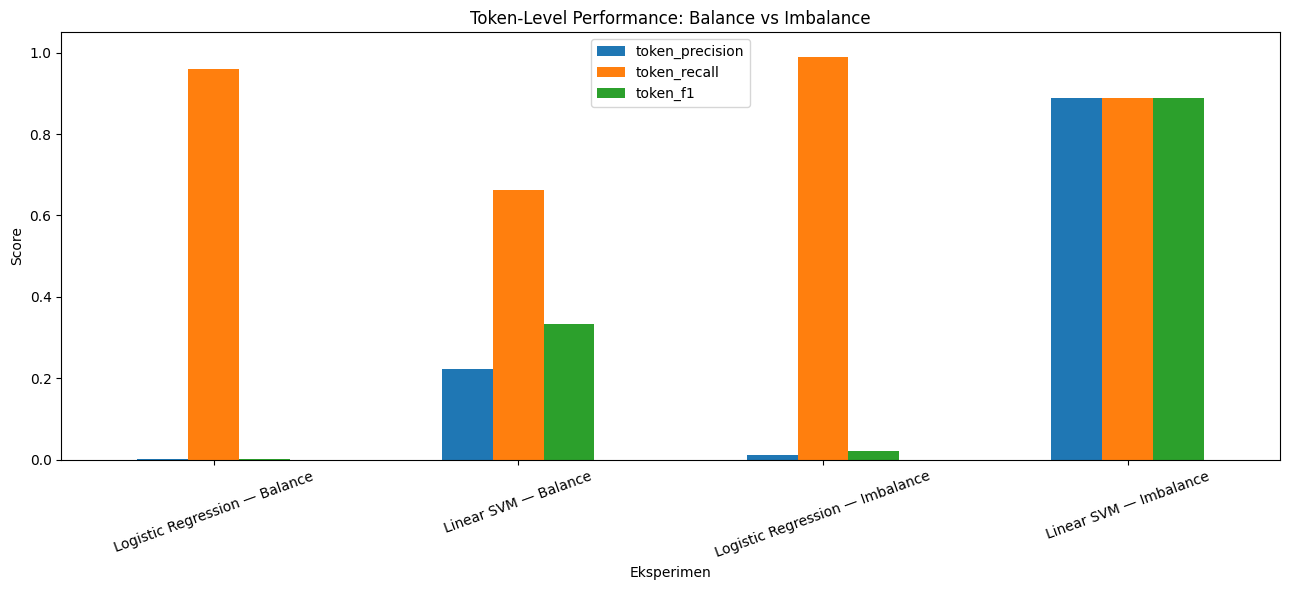

In [ ]:
plot_df = results_df.copy()
plot_df['experiment'] = plot_df['model'] + ' — ' + plot_df['scenario'].str.title()
ax = plot_df.set_index('experiment')[
    ['token_precision', 'token_recall', 'token_f1']
].plot(kind='bar', figsize=(13, 6))
ax.set_title('Token-Level Performance: Balance vs Imbalance')
ax.set_xlabel('Eksperimen')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'baseline_token_metrics_comparison.png', dpi=160, bbox_inches='tight')
plt.show()


### 21.2 Entity-level precision, recall, dan F1


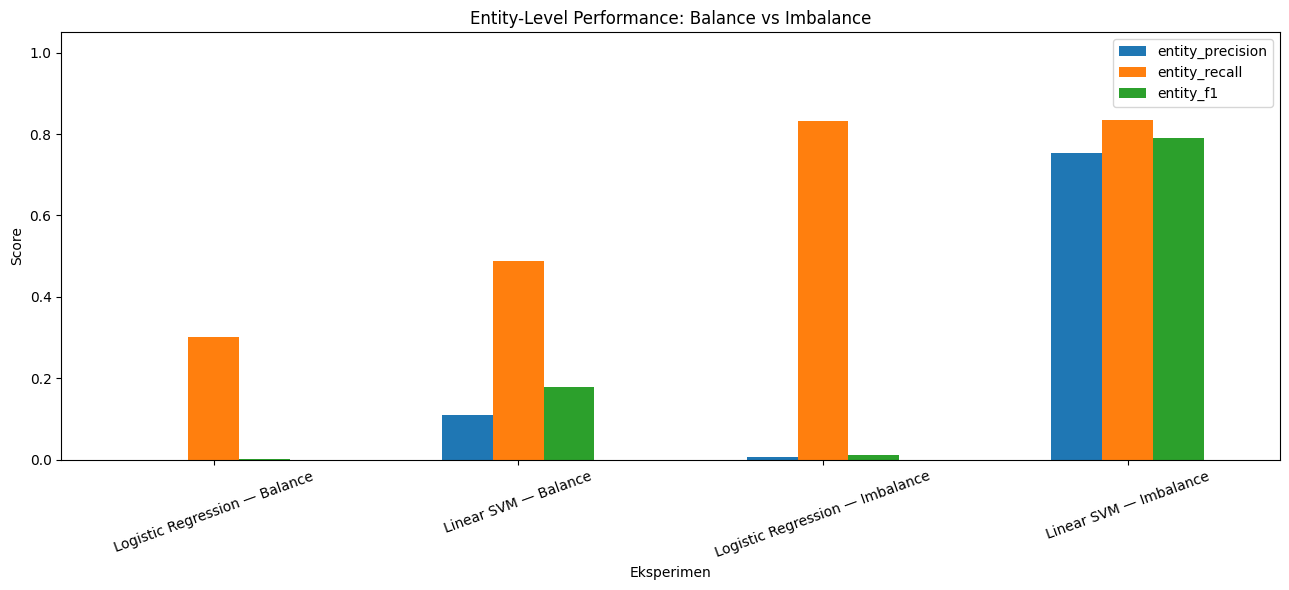

In [ ]:
ax = plot_df.set_index('experiment')[
    ['entity_precision', 'entity_recall', 'entity_f1']
].plot(kind='bar', figsize=(13, 6))
ax.set_title('Entity-Level Performance: Balance vs Imbalance')
ax.set_xlabel('Eksperimen')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'baseline_entity_metrics_comparison.png', dpi=160, bbox_inches='tight')
plt.show()


### 21.3 Perbandingan F1 balance vs imbalance untuk setiap model


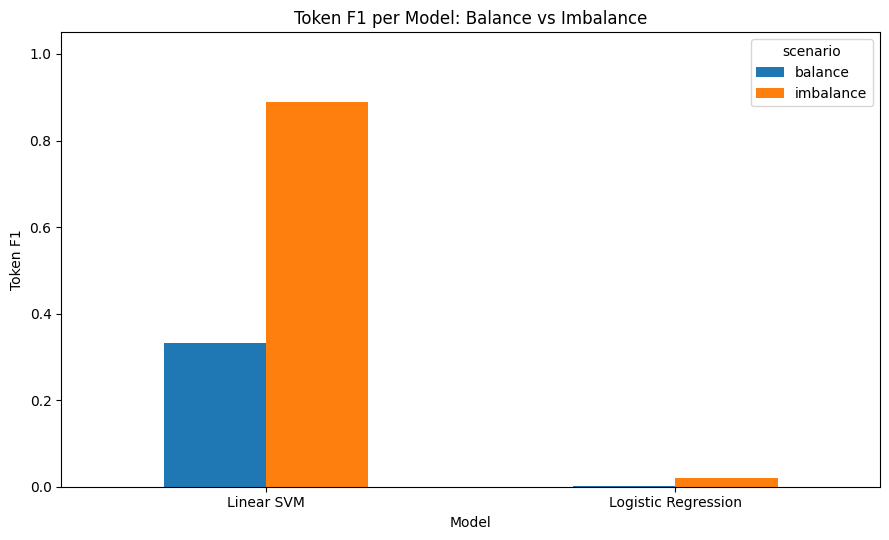

In [ ]:
f1_pivot = results_df.pivot(index='model', columns='scenario', values='token_f1')
ax = f1_pivot.plot(kind='bar', figsize=(9, 5.5))
ax.set_title('Token F1 per Model: Balance vs Imbalance')
ax.set_xlabel('Model')
ax.set_ylabel('Token F1')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'baseline_f1_balance_vs_imbalance.png', dpi=160, bbox_inches='tight')
plt.show()


### 21.4 Jumlah PII sebenarnya dan PII yang diprediksi


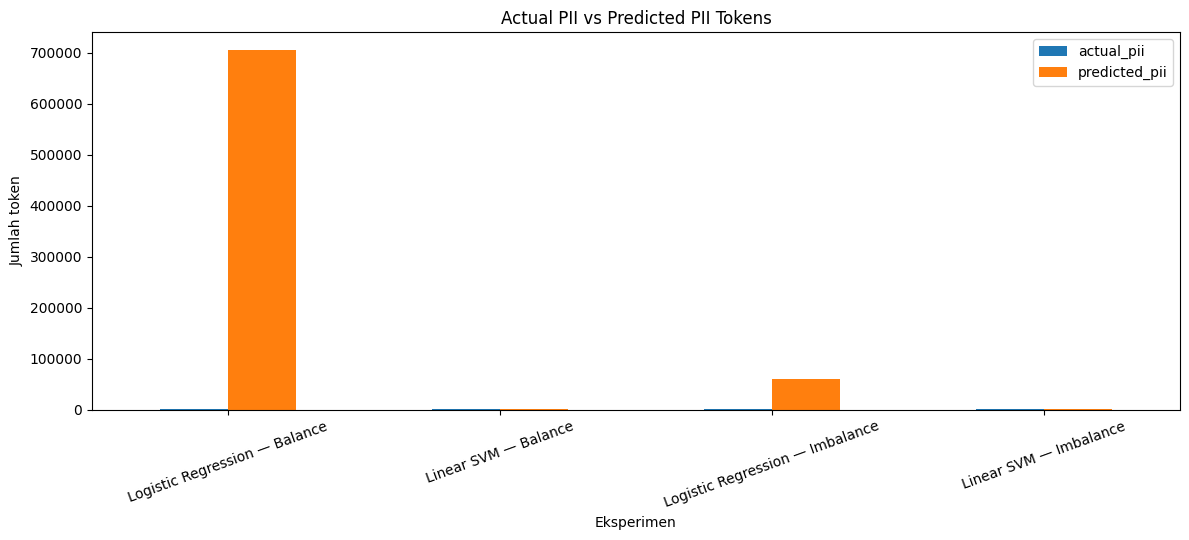

In [ ]:
prediction_count_plot = plot_df.set_index('experiment')[['actual_pii', 'predicted_pii']]
ax = prediction_count_plot.plot(kind='bar', figsize=(12, 5.5))
ax.set_title('Actual PII vs Predicted PII Tokens')
ax.set_xlabel('Eksperimen')
ax.set_ylabel('Jumlah token')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'actual_vs_predicted_pii.png', dpi=160, bbox_inches='tight')
plt.show()


## 22. Analisis per kelas PII

Micro F1 dapat didominasi label yang lebih banyak. Tabel dan grafik berikut memperlihatkan F1 setiap label agar kelemahan pada kelas langka tidak tersembunyi.


,model,scenario,experiment,label,precision,recall,f1,support
11,Linear SVM,balance,Linear SVM — Balance,B-EMAIL,0.363636,1.000000,0.533333,8
0,Logistic Regression,balance,Logistic Regression — Balance,B-EMAIL,0.000297,1.000000,0.000594,8
33,Linear SVM,imbalance,Linear SVM — Imbalance,B-EMAIL,1.000000,1.000000,1.000000,8
22,Logistic Regression,imbalance,Logistic Regression — Imbalance,B-EMAIL,0.108108,1.000000,0.195122,8
12,Linear SVM,balance,Linear SVM — Balance,B-ID_NUM,0.326087,0.600000,0.422535,25
1,Logistic Regression,balance,Logistic Regression — Balance,B-ID_NUM,0.002697,0.720000,0.005374,25
34,Linear SVM,imbalance,Linear SVM — Imbalance,B-ID_NUM,1.000000,0.880000,0.936170,25
23,Logistic Regression,imbalance,Logistic Regression — Imbalance,B-ID_NUM,0.004145,1.000000,0.008255,25
13,Linear SVM,balance,Linear SVM — Balance,B-NAME_STUDENT,0.259043,0.693750,0.377230,320
2,Logistic Regression,balance,Logistic Regression — Balance,B-NAME_STUDENT,0.002397,0.984375,0.004783,320


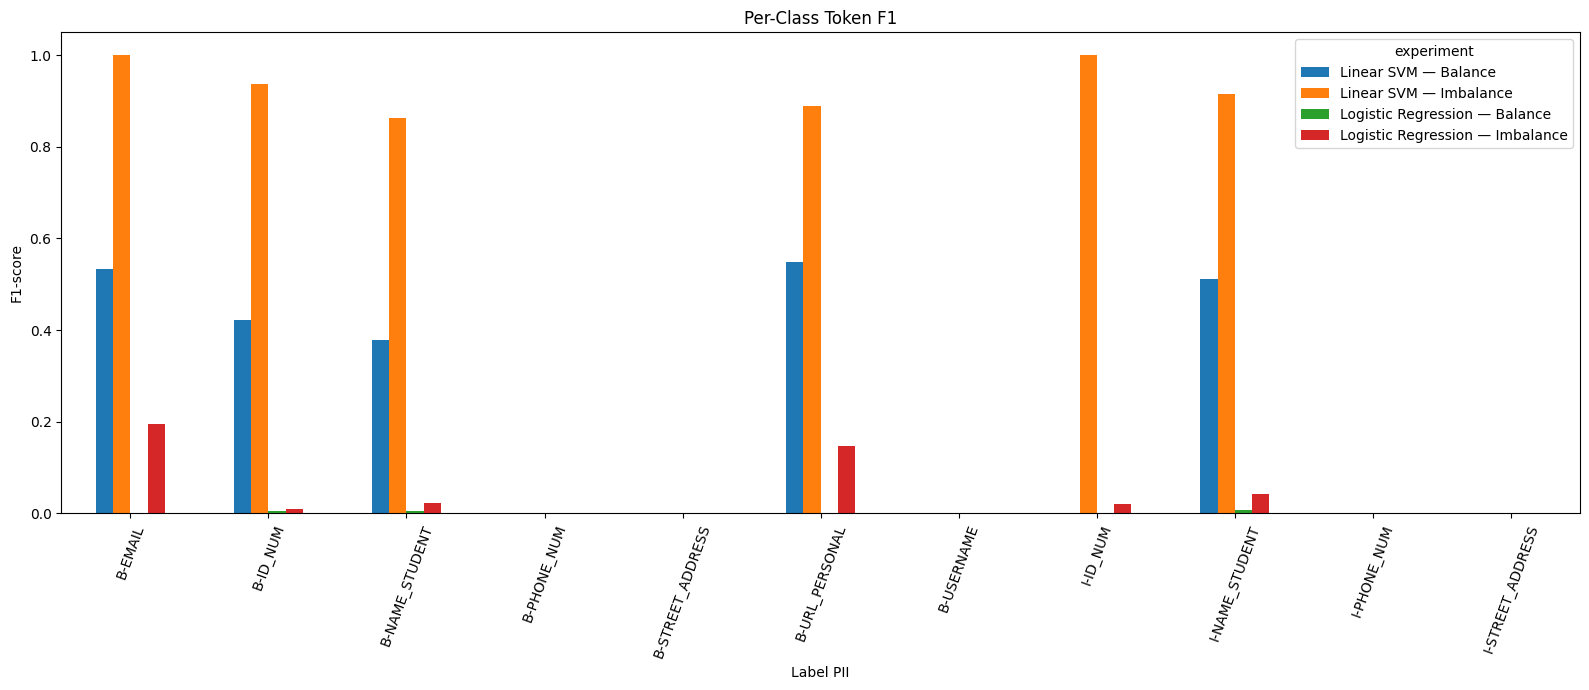

In [ ]:
per_class_rows = []
for model_name, scenario, stem in EXPERIMENTS:
    per_class = metric_map[stem]['token_level']['per_class']
    for label, values in per_class.items():
        per_class_rows.append({
            'model': model_name,
            'scenario': scenario,
            'experiment': f'{model_name} — {scenario.title()}',
            'label': label,
            'precision': values['precision'],
            'recall': values['recall'],
            'f1': values['f1'],
            'support': values['tp'] + values['fn'],
        })

per_class_df = pd.DataFrame(per_class_rows)
display(per_class_df.sort_values(['label', 'scenario', 'model']))

per_class_f1 = per_class_df.pivot_table(
    index='label', columns='experiment', values='f1', aggfunc='first'
).fillna(0)
ax = per_class_f1.plot(kind='bar', figsize=(16, 7))
ax.set_title('Per-Class Token F1')
ax.set_xlabel('Label PII')
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=70)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'baseline_per_class_f1.png', dpi=160, bbox_inches='tight')
plt.show()


## 23. Pemilihan baseline akhir — hanya berdasarkan dataset balance

Sesuai ketentuan eksperimen, hasil imbalance hanya dipakai untuk memahami pengaruh distribusi data. **Hasil imbalance tidak ikut menentukan pemenang akhir.**

Pemilihan antara Logistic Regression dan Linear SVM menggunakan:

1. token F1 pada `data/processed/balance/test.json` sebagai kriteria utama;
2. entity F1 sebagai indikator kualitas entitas lengkap;
3. precision, recall, false positive, dan missed PII sebagai analisis risiko.


In [ ]:
FINAL_SELECTED_MODEL = best_balance['model']

print('=' * 72)
print('PEMILIHAN BASELINE AKHIR — DATASET BALANCE SAJA')
print('=' * 72)
print(f"Model terpilih       : {FINAL_SELECTED_MODEL}")
print(f"Token precision      : {best_balance['token_precision']:.4f}")
print(f"Token recall         : {best_balance['token_recall']:.4f}")
print(f"Token F1             : {best_balance['token_f1']:.4f}")
print(f"Entity F1            : {best_balance['entity_f1']:.4f}")
print(f"False positive nonPII: {best_balance['non_pii_false_positive']:,.0f}")
print(f"Missed PII           : {best_balance['missed_pii']:,.0f}")
print('\nHasil skenario imbalance tidak digunakan dalam keputusan final ini.')


PEMILIHAN BASELINE AKHIR — DATASET BALANCE SAJA
Model terpilih       : Linear SVM
Token precision      : 0.2224
Token recall         : 0.6626
Token F1             : 0.3331
Entity F1            : 0.1781
False positive nonPII: 1,492
Missed PII           : 190

Hasil skenario imbalance tidak digunakan dalam keputusan final ini.


## 24. Kesimpulan otomatis untuk laporan

Sel berikut menghasilkan paragraf kesimpulan berdasarkan hasil aktual. Teksnya dapat digunakan sebagai dasar laporan setelah diperiksa kembali.


In [ ]:
def metric_sentence(row):
    return (
        f"token precision {row['token_precision']:.4f}, token recall "
        f"{row['token_recall']:.4f}, token F1 {row['token_f1']:.4f}, "
        f"dan entity F1 {row['entity_f1']:.4f}"
    )

logreg_delta = balance_vs_imbalance_df[
    balance_vs_imbalance_df['model'] == 'Logistic Regression'
].iloc[0]
svm_delta = balance_vs_imbalance_df[
    balance_vs_imbalance_df['model'] == 'Linear SVM'
].iloc[0]

paragraphs = []
paragraphs.append(
    f"Pada skenario imbalance, model terbaik adalah {best_imbalance['model']} dengan "
    f"{metric_sentence(best_imbalance)}. Pada skenario balance, model terbaik adalah "
    f"{best_balance['model']} dengan {metric_sentence(best_balance)}."
)

if best_imbalance['model'] != best_balance['model']:
    reason = (
        'Perbedaan pemenang menunjukkan bahwa Logistic Regression dan Linear SVM '
        'merespons perubahan distribusi kelas secara berbeda.'
    )
    if not TEST_SETS_IDENTICAL:
        reason += (
            ' Selain itu, karena test.json kedua skenario tidak identik, perbedaan '
            'tingkat kesulitan test juga dapat memengaruhi hasil.'
        )
    paragraphs.append(reason)
else:
    paragraphs.append(
        f"{best_balance['model']} tetap unggul pada kedua skenario, sehingga performanya "
        'lebih stabil terhadap perubahan distribusi training pada eksperimen ini.'
    )

paragraphs.append(
    f"Untuk Logistic Regression, perubahan balance terhadap imbalance menghasilkan "
    f"delta token F1 {logreg_delta['delta_token_f1']:+.4f} dan delta entity F1 "
    f"{logreg_delta['delta_entity_f1']:+.4f}. Untuk Linear SVM, delta token F1 adalah "
    f"{svm_delta['delta_token_f1']:+.4f} dan delta entity F1 "
    f"{svm_delta['delta_entity_f1']:+.4f}."
)

paragraphs.append(
    f"Pemilihan baseline akhir hanya menggunakan hasil dataset balance. Berdasarkan "
    f"token F1 tertinggi pada balance/test.json, model yang dipilih adalah "
    f"{FINAL_SELECTED_MODEL}."
)

for paragraph in paragraphs:
    display(Markdown(paragraph))


Pada skenario imbalance, model terbaik adalah Linear SVM dengan token precision 0.8877, token recall 0.8891, token F1 0.8884, dan entity F1 0.7910. Pada skenario balance, model terbaik adalah Linear SVM dengan token precision 0.2224, token recall 0.6626, token F1 0.3331, dan entity F1 0.1781.

Linear SVM tetap unggul pada kedua skenario, sehingga performanya lebih stabil terhadap perubahan distribusi training pada eksperimen ini.

Untuk Logistic Regression, perubahan balance terhadap imbalance menghasilkan delta token F1 -0.0195 dan delta entity F1 -0.0121. Untuk Linear SVM, delta token F1 adalah -0.5553 dan delta entity F1 -0.6129.

Pemilihan baseline akhir hanya menggunakan hasil dataset balance. Berdasarkan token F1 tertinggi pada balance/test.json, model yang dipilih adalah Linear SVM.

## 25. Ekspor ringkasan hasil ke Markdown

Ringkasan otomatis disimpan ke:

```text
results/baseline_balance_imbalance_summary.md
```


In [ ]:
summary_output = BASE_DIR / 'results' / 'baseline_balance_imbalance_summary.md'

result_table_md = results_df[[
    'model', 'scenario', 'token_precision', 'token_recall', 'token_f1',
    'entity_precision', 'entity_recall', 'entity_f1',
    'non_pii_false_positive', 'missed_pii', 'wrong_pii_label'
]].to_markdown(index=False)

comparison_table_md = balance_vs_imbalance_df.to_markdown(index=False)

content = f"""# Ringkasan Baseline: Balance vs Imbalance

## Hasil Empat Eksperimen

{result_table_md}

## Model Terbaik per Skenario

- Imbalance: **{best_imbalance['model']}** — token F1 `{best_imbalance['token_f1']:.4f}`.
- Balance: **{best_balance['model']}** — token F1 `{best_balance['token_f1']:.4f}`.

## Perbandingan Balance terhadap Imbalance

{comparison_table_md}

## Pemilihan Baseline Akhir

Baseline akhir dipilih **hanya dari hasil dataset balance**. Model terpilih adalah
**{FINAL_SELECTED_MODEL}**, dengan token F1 `{best_balance['token_f1']:.4f}` dan
entity F1 `{best_balance['entity_f1']:.4f}` pada `data/processed/balance/test.json`.

## Kesetaraan Test Set

Test balance dan imbalance identik: **{TEST_SETS_IDENTICAL}**.
"""

summary_output.write_text(content, encoding='utf-8')
print('Ringkasan tersimpan:', summary_output.relative_to(BASE_DIR))


ImportError: `Import tabulate` failed.  Use pip or conda to install the tabulate package.

## 26. Daftar output

### Trained models

```text
models/baseline/logistic_regression_balance_model.joblib
models/baseline/linear_svm_balance_model.joblib
models/baseline/logistic_regression_imbalance_model.joblib
models/baseline/linear_svm_imbalance_model.joblib
```

### Test predictions

```text
results/predictions/logistic_regression_balance_predictions.csv
results/predictions/linear_svm_balance_predictions.csv
results/predictions/logistic_regression_imbalance_predictions.csv
results/predictions/linear_svm_imbalance_predictions.csv
```

### Metrics

```text
results/metrics/logistic_regression_balance_metrics.json
results/metrics/linear_svm_balance_metrics.json
results/metrics/logistic_regression_imbalance_metrics.json
results/metrics/linear_svm_imbalance_metrics.json
```

### Plots

```text
models/baseline/plots/dataset_pii_ratio.png
models/baseline/plots/train_pii_label_distribution.png
models/baseline/plots/baseline_token_metrics_comparison.png
models/baseline/plots/baseline_entity_metrics_comparison.png
models/baseline/plots/baseline_f1_balance_vs_imbalance.png
models/baseline/plots/actual_vs_predicted_pii.png
models/baseline/plots/baseline_per_class_f1.png
```
